# Heart Disease Prediction Using Classical Machine Learning Techniques
_____________________________________

## 1. Problem Statement

Heart disease remains one of the leading causes of mortality worldwide, and early detection is essential for effective treatment and prevention.

Therefore, the task of detecting heart problems at early stages is very important. Of course, people can check their heart health in clinics or hospitals. However, many people do not visit medical institutions regularly or in time.

For this reason, systems for early detection of heart diseases are needed. Such systems can be integrated into fitness bands or smartwatches, which have become an essential part of our daily lives. A device could potentially predict possible health problems, warn the user, and recommend visiting a doctor.

## 2. Classification Model

However, the computational resources of such devices are limited. Therefore, using complex neural networks may not always be practical.

Instead, classical machine learning algorithms can be applied, as they are efficient for many classification tasks. In this project, the following models will be considered:

- **Random Forest**
- **Logistic Regression**
- **k-Nearest Neighbors**

The models will be compared using the **accuracy score**, and the best-performing model will be selected.

## 3. Data loading

The dataset used in this project is publicly available on Kaggle:

https://www.kaggle.com/datasets/algozee/heart-decices/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv('train.csv')
data.drop('id', axis=1, inplace=True)
data.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## 4. Dataset Description

The dataset contains the following columns:

- **Age** — Age of the patient (*int*).
- **Sex** — Gender of the patient (*bool*).
- **Chest Pain Type** — Type of chest pain experienced by the patient (*int*, values: [1, 2, 3, 4]).
- **BP** — Resting blood pressure (*int*).
- **Cholesterol** — Serum cholesterol level (*int*).
- **FBS over 120** — Fasting blood sugar greater than 120 mg/dl (*bool*, 1 = yes, 0 = no).
- **EKG Results** — Resting electrocardiographic results (*int*, values: [0, 1, 2]).
- **Max HR** — Maximum heart rate achieved (*int*).
- **Exercise Angina** — Exercise-induced angina (*bool*, 1 = yes, 0 = no).
- **ST Depression** — ST segment depression induced by exercise relative to rest, measured on an ECG (*float*).
- **Slope of ST** — The slope of the ST segment during peak exercise (*int*, values: [1, 2, 3]).
- **Number of Vessels (Fluoroscopy)** — Number of major coronary vessels visualized during fluoroscopy (*int*, values: [0, 1, 2, 3]).
- **Thallium** — Result of the thallium stress test (*int*, 3 = normal, 6 = fixed defect, 7 = reversible defect).
- **Heart Disease** — Target variable indicating whether the patient has heart disease (*categorical*: 'Presence', 'Absence').

The dataset contains **630,000 rows** and **does not contain missing values (NaN)**.


### Feature Types

For the purpose of analysis and preprocessing, the features can be divided into several groups.

**Numerical (continuous) features:**
- Age
- BP
- Cholesterol
- Max HR
- ST Depression (*float, continuous*)

These features represent continuous numerical measurements.

**Binary features:**
- Sex
- FBS over 120
- Exercise Angina

These variables contain only two possible values (0 or 1).

**Categorical features:**
- Chest Pain Type
- EKG Results
- Slope of ST
- Number of Vessels (Fluoroscopy)
- Thallium

These features represent discrete categories rather than continuous measurements.

**Target variable:**
- Heart Disease (*categorical*: 'Presence' / 'Absence')

This is the variable we want to predict.

## 5. Correlation Matrix and Distribution Analysis

In [3]:
data['Heart Disease'] = data['Heart Disease'].map({'Absence': 0, 'Presence': 1})

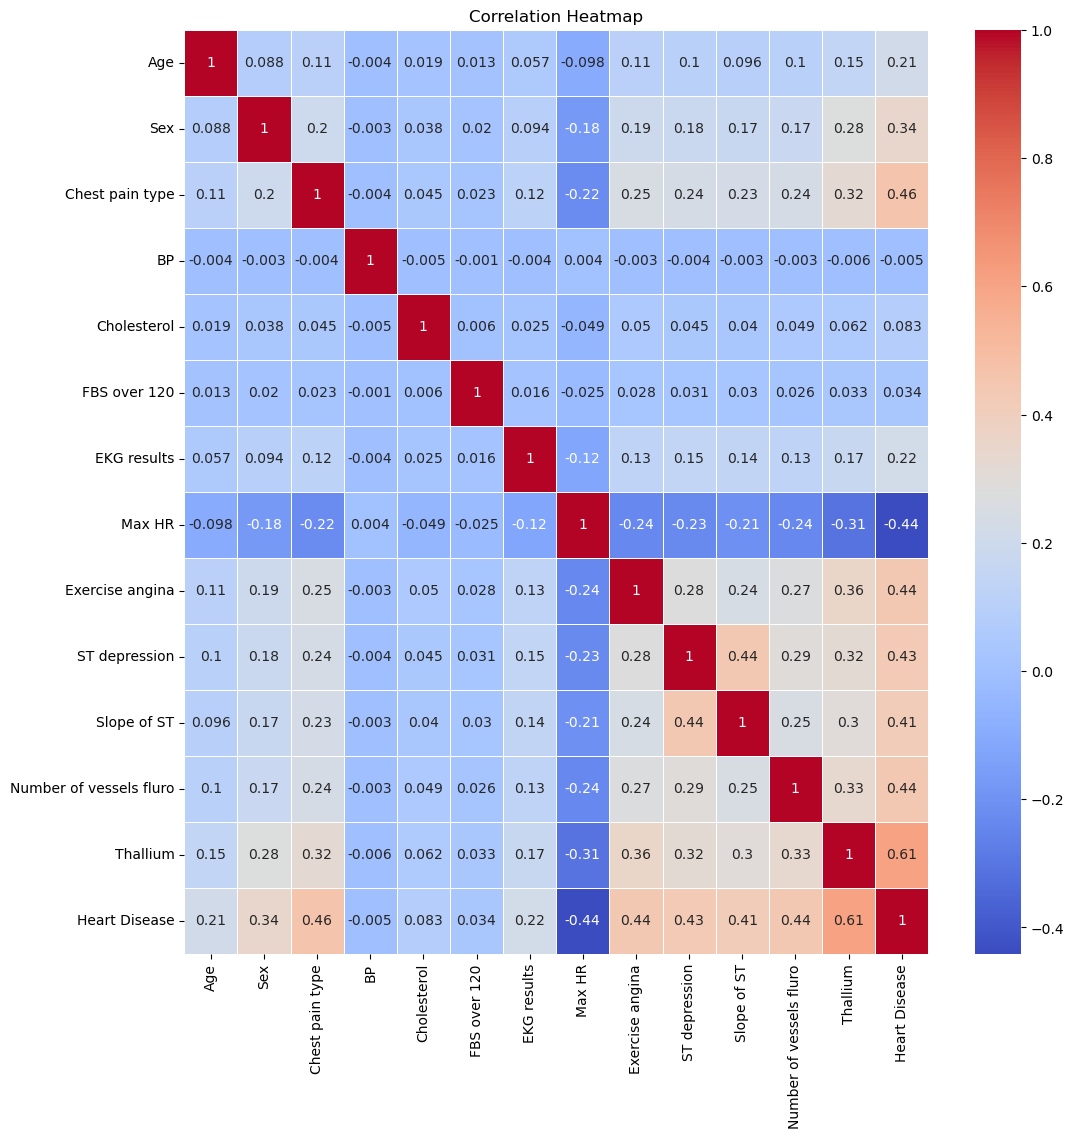

In [4]:
# build a correlation heatmap
corr = data.corr().round(3)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Let's plot the distributions of variables that have a high absolute correlation with the target variable.

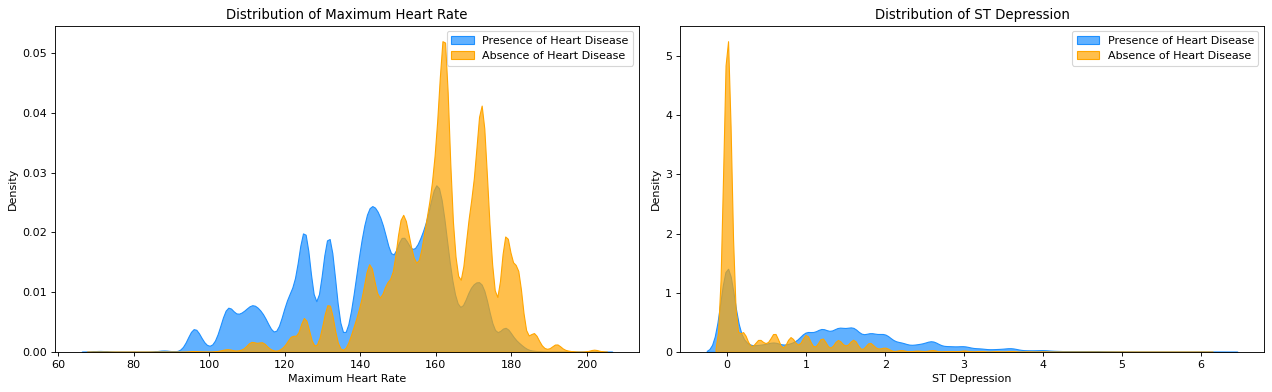

In [5]:
#distributions for numerical features
fig, ax = plt.subplots(1, 2, figsize=(16,5), dpi=80)

# Max HR
sns.kdeplot(data[data['Heart Disease']==1]['Max HR'], fill=True,
            color="dodgerblue", label='Presence of Heart Disease',
            alpha=.7, ax=ax[0])

sns.kdeplot(data[data['Heart Disease']==0]['Max HR'], fill=True,
            color="orange", label='Absence of Heart Disease',
            alpha=.7, ax=ax[0])

ax[0].set_title('Distribution of Maximum Heart Rate', fontsize=12)
ax[0].set_xlabel('Maximum Heart Rate')
ax[0].set_ylabel('Density')
ax[0].legend()


# ST Depression
sns.kdeplot(data[data['Heart Disease']==1]['ST depression'], fill=True,
            color="dodgerblue", label='Presence of Heart Disease',
            alpha=.7, ax=ax[1])

sns.kdeplot(data[data['Heart Disease']==0]['ST depression'], fill=True,
            color="orange", label='Absence of Heart Disease',
            alpha=.7, ax=ax[1])

ax[1].set_title('Distribution of ST Depression', fontsize=12)
ax[1].set_xlabel('ST Depression')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.tight_layout()
plt.show()

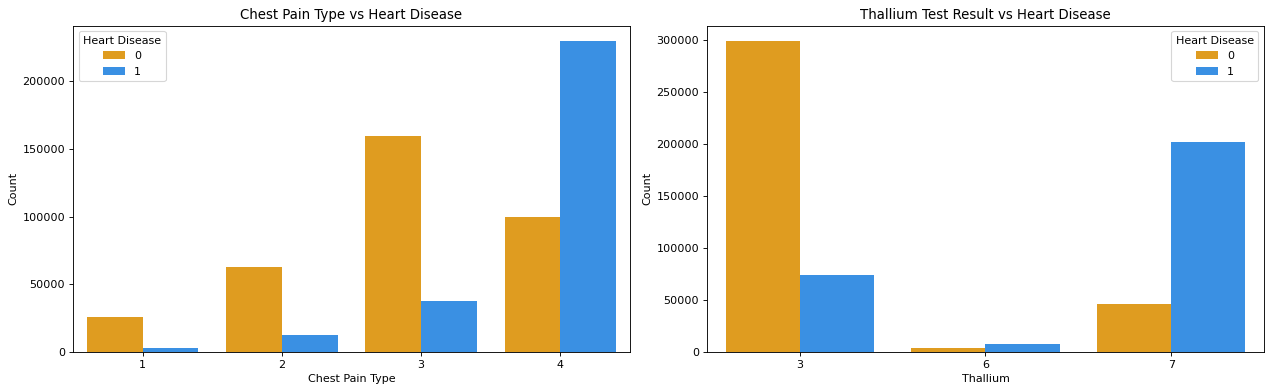

In [6]:
# distributions for categorical features
fig, ax = plt.subplots(1, 2, figsize=(16,5), dpi=80)

# Chest Pain Type
sns.countplot(data=data, x='Chest pain type', hue='Heart Disease',
              palette=['orange','dodgerblue'], ax=ax[0])

ax[0].set_title('Chest Pain Type vs Heart Disease', fontsize=12)
ax[0].set_xlabel('Chest Pain Type')
ax[0].set_ylabel('Count')


# Thallium
sns.countplot(data=data, x='Thallium', hue='Heart Disease',
              palette=['orange','dodgerblue'], ax=ax[1])

ax[1].set_title('Thallium Test Result vs Heart Disease', fontsize=12)
ax[1].set_xlabel('Thallium')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

As we can see, the distributions have a rather complex shape and contain several local extrema, indicating multimodal distributions.

Next, we plot the distribution of **Heart Disease** to examine the class balance.

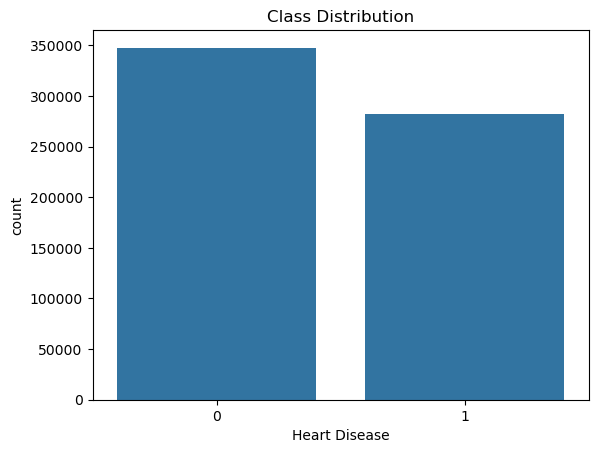

In [7]:
sns.countplot(x='Heart Disease', data=data)
plt.title('Class Distribution')
plt.show()

As we can see from the previous histogram, there is no significant class imbalance in the dataset. Therefore, we can use the **accuracy score** as a metric for model evaluation.

## 6. Dataset Preprocessing

Next, we need to perform some preprocessing. For numerical and categorical ordered features, we will apply standardization. For categorical unordered features, we will use one-hot encoding. 
This preprocessing is essential for Logistic Regression and k-NN models.

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Feature lists
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

categorical_features = ['Chest pain type', 'EKG results']

passthrough_features = ['Sex', 'FBS over 120', 'Exercise angina']

scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, drop='first')

def preprocess_data(df, fit=False):

    # Numerical
    X_num = df[numerical_features].copy()

    if fit:
        scaler.fit(X_num)

    X_num_scaled = scaler.transform(X_num)


    # Categorical
    X_cat = df[categorical_features].copy()

    if fit:
        encoder.fit(X_cat)

    X_cat_encoded = encoder.transform(X_cat)
    cat_cols = encoder.get_feature_names_out(categorical_features)


    # Passthrough
    X_pass = df[passthrough_features].copy()


    # Combine
    X_combined = np.hstack([X_num_scaled, X_cat_encoded, X_pass.values])

    all_cols = list(numerical_features) + list(cat_cols) + list(passthrough_features)
    X_df = pd.DataFrame(X_combined, columns=all_cols)

    return X_df

# 3. Prepare the data
X_processed = preprocess_data(data.drop('Heart Disease', axis=1), fit=True)
y = data['Heart Disease'].values

Preprocessed dataset:

In [13]:
X_processed.head()

,Age,BP,Cholesterol,Max HR,ST depression,Slope of ST,Number of vessels fluro,Thallium,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Sex,FBS over 120,Exercise angina
0,0.467921,1.435822,-0.178490,0.271190,3.040655,0.998051,1.939721,1.221087,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,-0.258797,-0.367088,2.374837,0.951359,-0.754928,-0.836168,-0.564825,-0.830189,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.225682,1.970017,-1.692672,-0.095054,-0.754928,-0.836168,-0.564825,-0.830189,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.227755,0.233882,-0.475388,-0.147375,0.299400,0.998051,-0.564825,-0.830189,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.467921,0.634529,-0.326939,-1.455391,3.251520,0.998051,3.191993,-0.830189,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0


## 7. Model Comparison

Next, we will compare the performance of four classical machine learning models for heart disease prediction:

- Logistic Regression
- k-Nearest Neighbors (k-NN)
- Random Forest

To select the best hyperparameters for each model, we will apply GridSearchCV with cross-validation.
The Accuracy score will be used as the primary metric, since the target classes are fairly balanced.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# 1. Logistic Regression
lr_param_grid = [{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}]
gs_lr = GridSearchCV(LogisticRegression(solver='liblinear'), param_grid=lr_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
gs_lr.fit(X_processed, y)
print("Best Logistic Regression Params:", gs_lr.best_params_)
print("Best Logistic Regression CV Accuracy:", gs_lr.best_score_)

Best Logistic Regression Params: {'C': 100, 'penalty': 'l1'}
Best Logistic Regression CV Accuracy: 0.8849587301587303


In [ ]:
# 2. Random Forest
rf_param_grid = [{'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}]
gs_rf = GridSearchCV(RandomForestClassifier(random_state=1), param_grid=rf_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
gs_rf.fit(X_processed, y)
print("Best Random Forest Params:", gs_rf.best_params_)
print("Best Random Forest CV Accuracy:", gs_rf.best_score_)

Best Random Forest Params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
Best Random Forest CV Accuracy: 0.8849523809523809


In [19]:
# 3. K-Nearest Neighbors
knn_param_grid = [{'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}]
gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid=knn_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
gs_knn.fit(X_processed, y)
print("Best KNN Params:", gs_knn.best_params_)
print("Best KNN CV Accuracy:", gs_knn.best_score_)

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best KNN CV Accuracy: 0.8769285714285715


Logistic Regression achieved the highest accuracy (0.884959) while requiring significantly less training time compared to other models. Random Forest showed nearly identical performance but required substantially longer training time. K-Nearest Neighbors performed slightly worse. **Therefore, Logistic Regression was selected as the final model.**

## 8. Testing best model on new data

In [9]:
# split the data into train and test sets
from sklearn.model_selection import train_test_split

X = data.drop('Heart Disease', axis=1)
y = data['Heart Disease']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

# preprocess the train and test sets
X_train_processed = preprocess_data(X_train, fit=True)
X_test_processed = preprocess_data(X_test)


# train the best model (Logistic Regression) on the training data
from sklearn.linear_model import LogisticRegression
best_model = LogisticRegression(C=100, penalty='l1', solver='liblinear')
best_model.fit(X_train_processed, y_train)

# make predictions on the test set
y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)[:,1]

### 8.1 Accuracy Score

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8847


### 8.2 ROC Curve

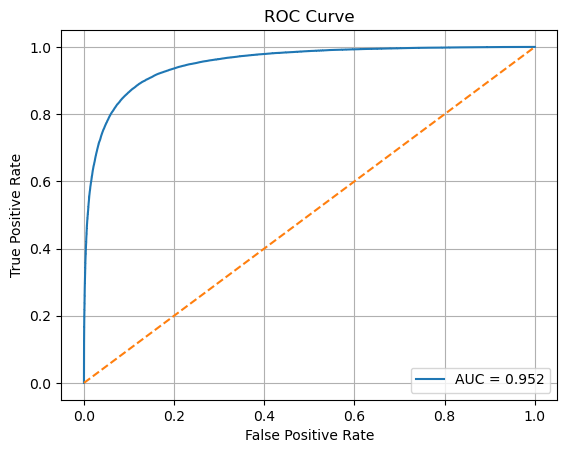

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.legend()
plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.3 Confusion Matrix

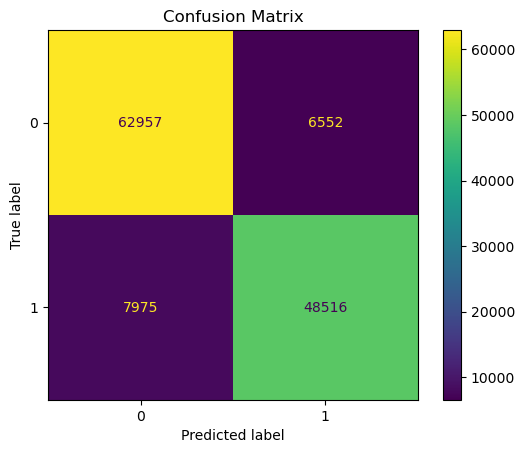

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

### 8.4 Feature Importance

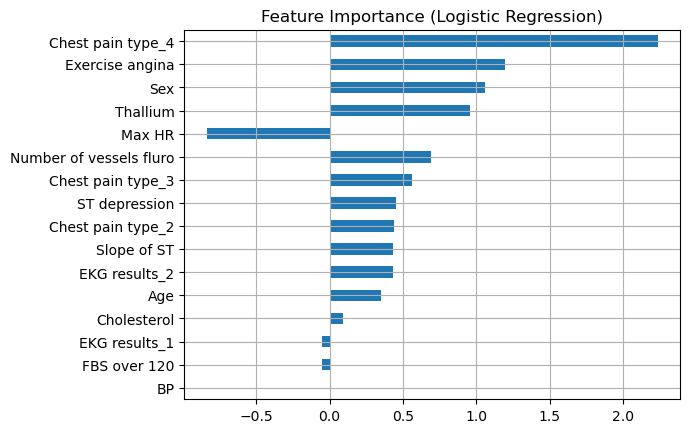

In [21]:
importance = pd.Series(
    best_model.coef_[0],
    index=X_train_processed.columns
)

importance = importance.sort_values(key=abs, ascending=False)
importance.plot(kind='barh')
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.grid()
plt.show()


In [19]:
importance

Chest pain type_4          2.235742
Exercise angina            1.193084
Sex                        1.060436
Thallium                   0.957810
Max HR                    -0.836433
Number of vessels fluro    0.692068
Chest pain type_3          0.560840
ST depression              0.453190
Chest pain type_2          0.441245
Slope of ST                0.434914
EKG results_2              0.433300
Age                        0.352241
Cholesterol                0.094889
EKG results_1             -0.049009
FBS over 120              -0.048972
BP                         0.004579
dtype: float64

# 9. Conclusion

In this project, a machine learning approach was applied to predict the presence of heart disease based on patient medical data. The dataset was explored, preprocessed, and used to train several classification models.

During the preprocessing stage, numerical features were standardized, categorical unordered features were encoded using one-hot encoding, and binary features were passed without transformation. This ensured that the data was suitable for machine learning algorithms such as Logistic Regression, Random Forest, and K-Nearest Neighbors.

Several models were trained and compared using cross-validation and hyperparameter tuning. Among the tested algorithms, Logistic Regression achieved the best overall performance while also being computationally efficient compared to more complex models.

The final model was evaluated on a separate test subset. The results demonstrate strong predictive performance:

* **Accuracy:** 0.8847
* **ROC AUC:** 0.952

The confusion matrix shows that the model correctly classifies the majority of patients while maintaining a good balance between false positives and false negatives. The ROC curve further confirms that the classifier has excellent ability to distinguish between patients with and without heart disease.

Feature importance analysis revealed that several variables play a particularly important role in predicting heart disease, including chest pain type, exercise-induced angina, thallium test results, and the number of vessels detected by fluoroscopy. These findings are consistent with known medical risk indicators.

Overall, the results indicate that even relatively simple machine learning models, such as Logistic Regression, can achieve strong predictive performance when combined with proper preprocessing and feature engineering. The developed model could potentially support clinical decision-making by assisting in the early identification of patients at higher risk of heart disease.

Future work could explore additional models, more advanced feature engineering techniques, or the use of other medical datasets to further improve predictive performance.
